In [52]:
import importlib

import pandas as pd

import model_functions
import utils
importlib.reload(model_functions)
importlib.reload(utils)

from model_functions import load_transition_matrix, gen_risk_matrix, gen_transition_probabilities, run_markov_cohort, \
    run_mc_sim, calculate_outcomes, plot_trace, load_costs, STAGE_ORDER, run_comparison

from utils import gen_cea

In [53]:
# GLOBAL base values
initial_prevalence = [.628, 0.309, 0.035, 0.016, 0.012, 0,0,0,0,0]

rr = [1, 1.56]  # relative risk of regression with treatment
pr = [1, 1] # relative risk of progression with treatment

baseline_tm_suffix = "_obs"



# Sensitivity Analyses

In [54]:
sensitivity_results = []

Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.30775002518132
Total Cost:  792621.0830550357
Discounted LY:  23.20717262454948
Discounted QALY:  19.8602431302864
Discounted Cost:  373684.80094529275
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  36.98039351461321
Total Cost:  1062834.4842712854
Discounted LY:  23.374514138192367
Discounted QALY:  20.069342406767017
Discounted Cost:  521514.4644388803


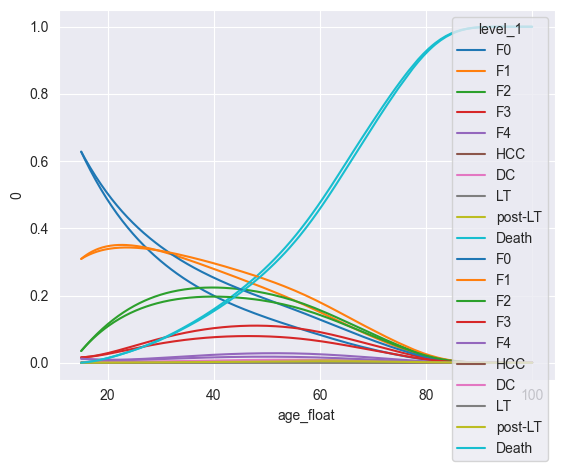

In [55]:
# Base Model
results, traces = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
                                 initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix)

sensitivity_results.append(['base', 'base', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying background re/progression rates

Running model for treatment: SOC
Total LY:  43.950021772383245
Total QALY:  36.74452378362178
Total Cost:  774302.5467680598
Discounted LY:  23.337482376343672
Discounted QALY:  20.00787029908213
Discounted Cost:  365437.1869059653
Running model for treatment: Semaglutide
Total LY:  44.25680508072556
Total QALY:  37.11813833842806
Total Cost:  1059195.4555346463
Discounted LY:  23.422064623646005
Discounted QALY:  20.121412766619745
Discounted Cost:  519170.5106976258
Running model for treatment: SOC
Total LY:  43.35449541102548
Total QALY:  36.16183607280931
Total Cost:  793845.6947542552
Discounted LY:  23.14961684419935
Discounted QALY:  19.793791493144845
Discounted Cost:  376074.193537817
Running model for treatment: Semaglutide
Total LY:  44.26124231723179
Total QALY:  37.159998350052284
Total Cost:  1053437.935742874
Discounted LY:  23.415805511683352
Discounted QALY:  20.116275798366456
Discounted Cost:  518369.0114933749
Running model for treatment: SOC
Total LY:  42.904283182

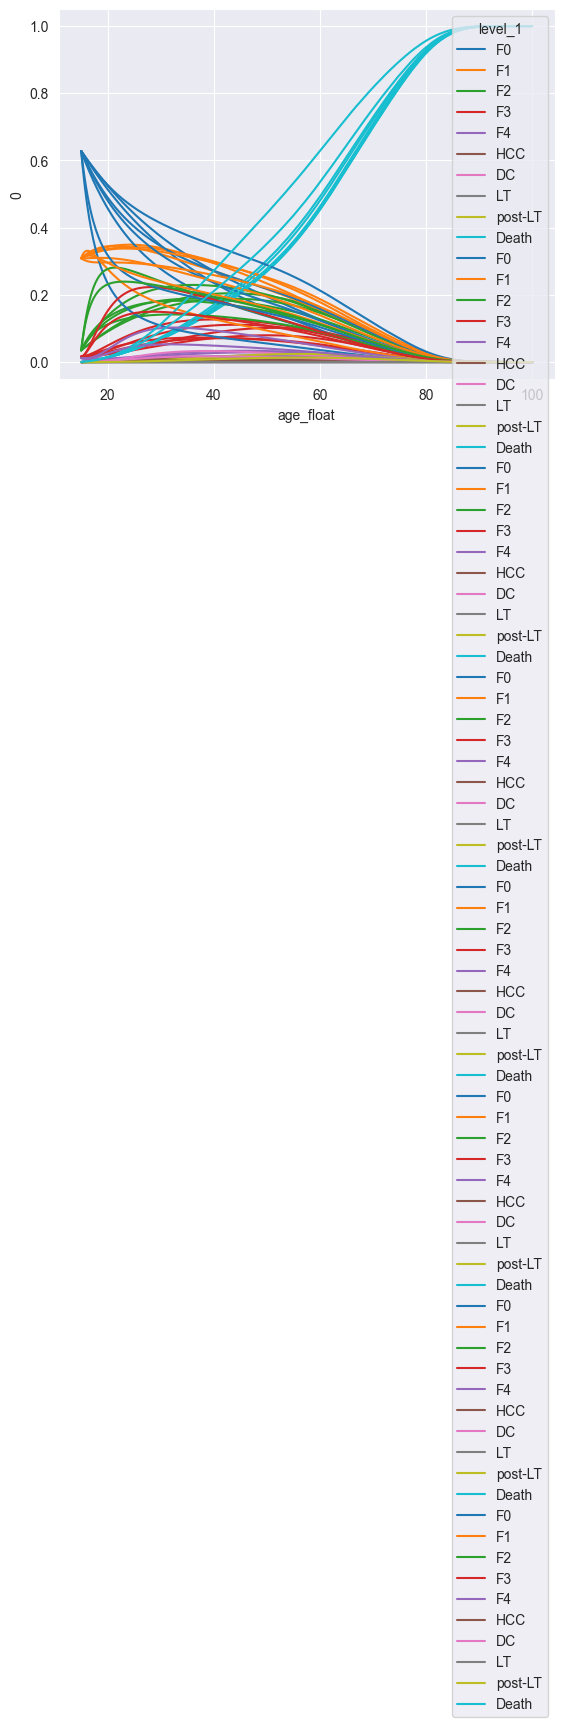

In [56]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_obs_low')
sensitivity_results.append(['progression_rate_obs', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_obs_high')
sensitivity_results.append(['progression_rate_obs', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_trial_low')
sensitivity_results.append(['progression_rate_trial', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, 
               transition_suffix='_trial_high')
sensitivity_results.append(['progression_rate_trial', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])


## Varying Regression Risk

## Varying Discount Rate

Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.30775002518132
Total Cost:  792621.0830550357
Discounted LY:  34.40349658526472
Discounted QALY:  28.968436114660946
Discounted Cost:  599281.0527005903
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  36.98039351461321
Total Cost:  1062834.4842712854
Discounted LY:  34.78440531881446
Discounted QALY:  29.41393428711914
Discounted Cost:  814789.7570917597
Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.30775002518132
Total Cost:  792621.0830550357
Discounted LY:  16.993752017104743
Discounted QALY:  14.732691450071266
Discounted Cost:  257170.0204910271
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  36.98039351461321
Total Cost:  1062834.4842712854
Discounted LY:  17.073198949234378
Discounted QALY:  14.839840444707914
Discounted Cost:  366981.63093667635


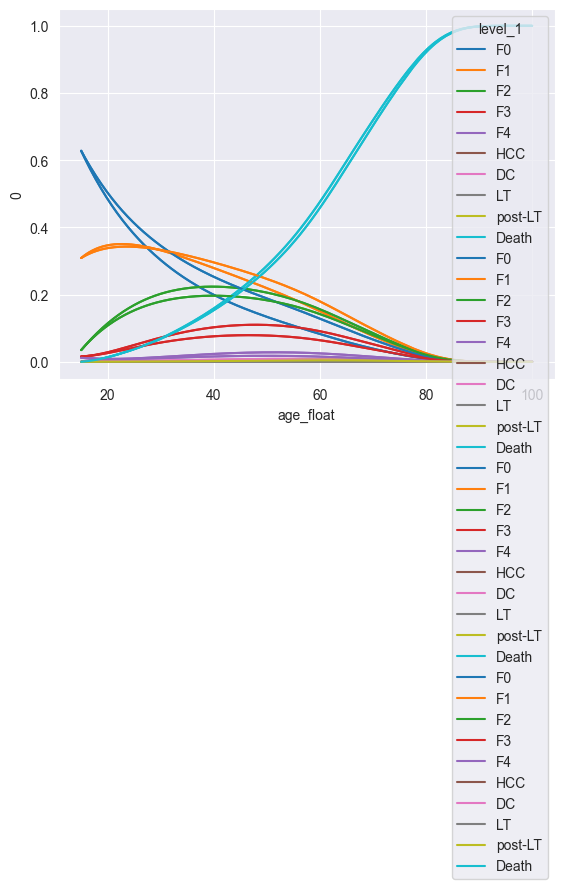

In [57]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               discount_rate = 0.01)
sensitivity_results.append(['discount_rate', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               discount_rate = 0.05)
sensitivity_results.append(['discount_rate', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying Treatment Costs

Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.30775002518132
Total Cost:  792621.0830550357
Discounted LY:  23.20717262454948
Discounted QALY:  19.8602431302864
Discounted Cost:  373684.80094529275
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  36.98039351461321
Total Cost:  891309.914758608
Discounted LY:  23.374514138192367
Discounted QALY:  20.069342406767017
Discounted Cost:  430610.9789554501
Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.30775002518132
Total Cost:  792621.0830550357
Discounted LY:  23.20717262454948
Discounted QALY:  19.8602431302864
Discounted Cost:  373684.80094529275
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  36.98039351461321
Total Cost:  1364027.9235106977
Discounted LY:  23.374514138192367
Discounted QALY:  20.069342406767017
Discounted Cost:  681139.021488596


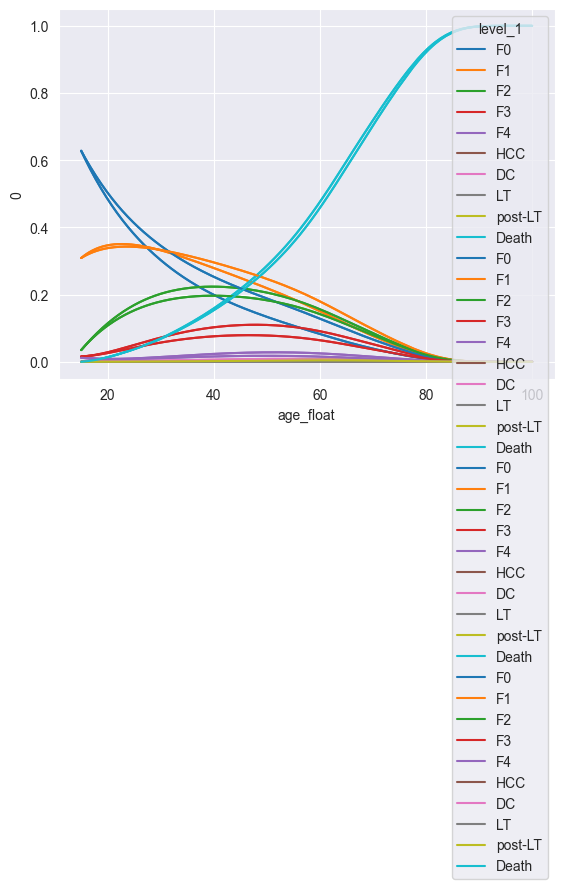

In [58]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               tx_cost_override=2940)
sensitivity_results.append(['treatment_cost', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               tx_cost_override=13658)
sensitivity_results.append(['treatment_cost', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying starting age (and prevalence)

Running model for treatment: SOC
Total LY:  46.04979466776912
Total QALY:  38.56638154496303
Total Cost:  832931.6125855129
Discounted LY:  23.925388644396055
Discounted QALY:  20.57198030631649
Discounted Cost:  379823.5174826523
Running model for treatment: Semaglutide
Total LY:  46.75331639839278
Total QALY:  39.35140342660195
Total Cost:  1118189.5331806066
Discounted LY:  24.114585269505515
Discounted QALY:  20.80478190433945
Discounted Cost:  531894.6703195898
Running model for treatment: SOC
Total LY:  41.0647146293355
Total QALY:  34.11949873277294
Total Cost:  753999.996306645
Discounted LY:  22.484339820039335
Discounted QALY:  19.13356183092847
Discounted Cost:  367695.7894883575
Running model for treatment: Semaglutide
Total LY:  41.559051699590064
Total QALY:  34.692695180007284
Total Cost:  1009776.9276080384
Discounted LY:  22.631287660593685
Discounted QALY:  19.32041222979902
Discounted Cost:  511262.3083591885


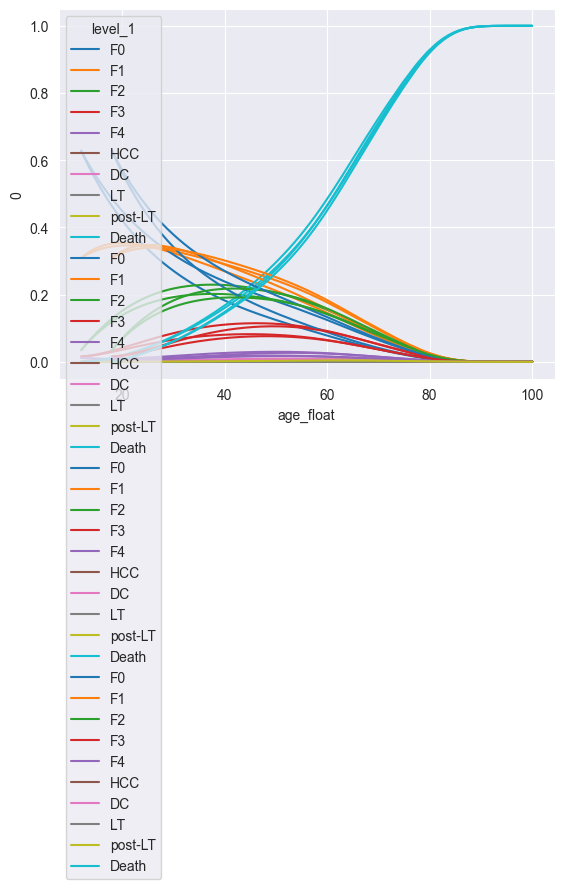

In [59]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               starting_age=12)
sensitivity_results.append(['starting_age', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
               starting_age=18)
sensitivity_results.append(['starting_age', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying other costs

Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.30775002518132
Total Cost:  680242.5437444332
Discounted LY:  23.20717262454948
Discounted QALY:  19.8602431302864
Discounted Cost:  318473.1595719982
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  36.98039351461321
Total Cost:  957851.9698578648
Discounted LY:  23.374514138192367
Discounted QALY:  20.069342406767017
Discounted Cost:  468972.2390975669
Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  36.30775002518132
Total Cost:  917926.4223538662
Discounted LY:  23.20717262454948
Discounted QALY:  19.8602431302864
Discounted Cost:  433182.2960511558
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  36.98039351461321
Total Cost:  1177763.3076152296
Discounted LY:  23.374514138192367
Discounted QALY:  20.069342406767017
Discounted Cost:  577504.8592680425


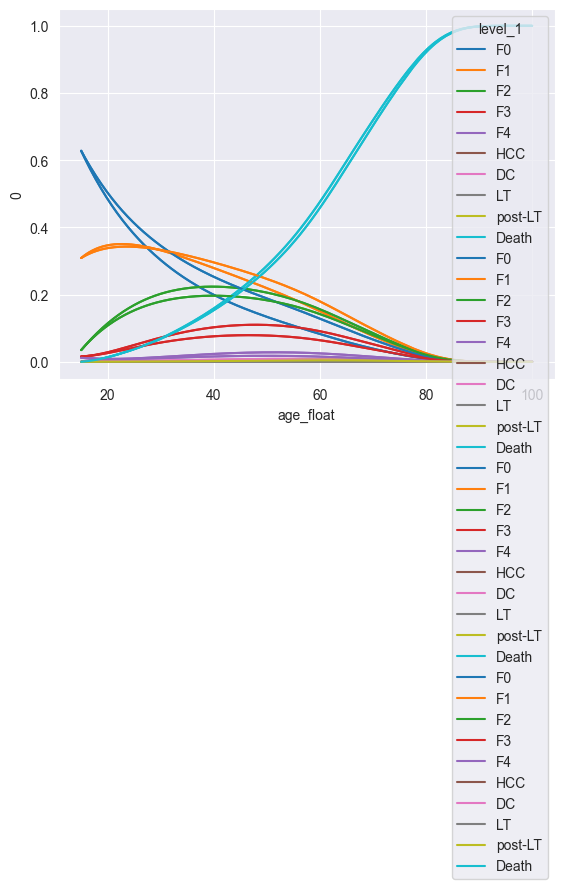

In [60]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            cost_suffix='_low', tx_cost_override=6829)
sensitivity_results.append(['cost', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            cost_suffix='_high', tx_cost_override=6829)
sensitivity_results.append(['cost', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Varying QALYs

Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  33.878770500918414
Total Cost:  792621.0830550357
Discounted LY:  23.20717262454948
Discounted QALY:  18.69046382572159
Discounted Cost:  373684.80094529275
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  34.70123339904487
Total Cost:  1062834.4842712854
Discounted LY:  23.374514138192367
Discounted QALY:  18.95951367466984
Discounted Cost:  521514.4644388803
Running model for treatment: SOC
Total LY:  43.51309823612231
Total QALY:  38.15040290643683
Total Cost:  792621.0830550357
Discounted LY:  23.20717262454948
Discounted QALY:  20.743154826427997
Discounted Cost:  373684.80094529275
Running model for treatment: Semaglutide
Total LY:  44.10505773018184
Total QALY:  38.75538477627703
Total Cost:  1062834.4842712854
Discounted LY:  23.374514138192367
Discounted QALY:  20.923966863622777
Discounted Cost:  521514.4644388803


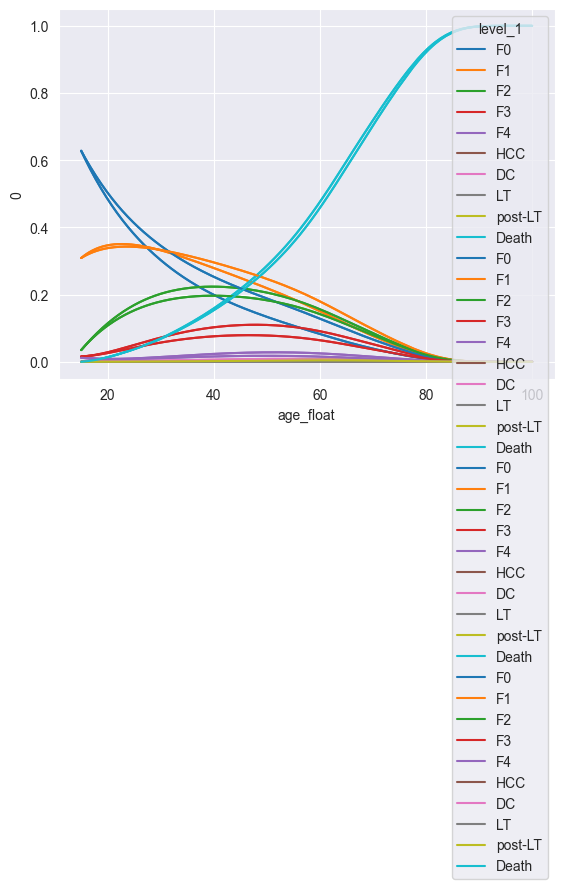

In [61]:
results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            qaly_stage_suffix='_low', qaly_age_suffix='_low')
sensitivity_results.append(['qalys', 'low', gen_cea(results).loc['Semaglutide', 'ICER']])

results, _ = run_comparison('~/Documents/courses/HRP_392/final_baseline_transition_probs.csv',
               initial_prevalence, ['SOC', 'Semaglutide'], rr=rr, pr=pr, transition_suffix=baseline_tm_suffix,
                            qaly_stage_suffix='_high', qaly_age_suffix='_high')
sensitivity_results.append(['qalys', 'high', gen_cea(results).loc['Semaglutide', 'ICER']])

## Plot Tornado Diagram

In [62]:
sensitivity_df = pd.DataFrame(sensitivity_results, columns=['variable', 'value', 'icer'])

In [63]:
sensitivity_df

,variable,value,icer
0,base,base,7.069831e+05
1,progression_rate_obs,low,1.353972e+06
2,progression_rate_obs,high,4.412457e+05
3,progression_rate_trial,low,3.359538e+05
4,progression_rate_trial,high,7.297130e+04
5,discount_rate,low,4.837477e+05
6,discount_rate,high,1.024850e+06
7,treatment_cost,low,2.722447e+05
8,treatment_cost,high,1.470374e+06
9,starting_age,low,6.532221e+05


In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def create_tornado_plot(sensitivity_df, threshold=None, figsize=(10, 8)):
    """
    Create a tornado plot from CEA sensitivity analysis results
    
    Parameters:
    -----------
    sensitivity_df : DataFrame with columns ['variable', 'value', 'icer']
                    - One row with variable='base', value='base'
                    - Pairs of rows for each parameter with value='low' and 'high'
    threshold : float, optional WTP threshold to display
    figsize : tuple, figure size
    """
    
    # Extract base case value
    base_value = sensitivity_df[sensitivity_df['value'] == 'base']['icer'].values[0]
    
    # Filter out base case and reshape
    sens_data = sensitivity_df[sensitivity_df['value'] != 'base'].copy()
    tornado_data = sens_data.pivot(index='variable', columns='value', values='icer')
    
    # Calculate range for sorting (absolute difference)
    tornado_data['range'] = abs(tornado_data['high'] - tornado_data['low'])
    tornado_data = tornado_data.sort_values('range', ascending=True)
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    y_pos = np.arange(len(tornado_data))
    
    # Plot bars for each variable
    for i, (idx, row) in enumerate(tornado_data.iterrows()):
        low_val = row['low']
        high_val = row['high']
        
        # Find actual min and max (don't assume low < high)
        left_val = min(low_val, high_val)
        right_val = max(low_val, high_val)
        width = right_val - left_val
        
        # Single color bar
        ax.barh(i, width, left=left_val, height=0.7,
                color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.5)
        
        # Add value labels at the ends
        # Label with "low" on the low value side, "high" on high value side
        if low_val < high_val:
            ax.text(low_val, i, f'  Low: ${low_val/1000:.0f}K', 
                    va='center', ha='right', fontsize=8, alpha=0.7)
            ax.text(high_val, i, f'High: ${high_val/1000:.0f}K  ', 
                    va='center', ha='left', fontsize=8, alpha=0.7)
        else:
            ax.text(high_val, i, f'  High: ${high_val/1000:.0f}K', 
                    va='center', ha='right', fontsize=8, alpha=0.7)
            ax.text(low_val, i, f'Low: ${low_val/1000:.0f}K  ', 
                    va='center', ha='left', fontsize=8, alpha=0.7)
    
    # Base case line
    ax.axvline(x=base_value, color='black', linestyle='--', linewidth=2.5,
               label=f'Base Case: ${base_value/1000:.0f}K', zorder=10)
    
    # Optional WTP threshold
    if threshold:
        ax.axvline(x=threshold, color='green', linestyle=':', linewidth=2,
                   label=f'WTP Threshold: ${threshold/1000:.0f}K', zorder=10)
    
    # Formatting
    ax.set_yticks(y_pos)
    ax.set_yticklabels(tornado_data.index, fontsize=10)
    ax.set_xlabel('Incremental Cost-Effectiveness Ratio ($/QALY)', 
                  fontsize=12, fontweight='bold')
    ax.set_title('One-Way Sensitivity Analysis - Tornado Diagram',
                 fontsize=14, fontweight='bold', pad=20)
    
    # set x-axis limits
    ax.set_xlim(min(0, tornado_data['low'].min()*0.8), tornado_data['high'].max()*1.2)
    
    # Grid
    ax.grid(axis='x', alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Format x-axis
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
    
    # Legend
    ax.legend(loc='best', fontsize=10, framealpha=0.9)
    
    plt.tight_layout()
    
    # Print summary
    print("\n" + "="*60)
    print("SENSITIVITY ANALYSIS SUMMARY")
    print("="*60)
    print(f"\nBase Case ICER: ${base_value:,.0f}")
    print(f"\nParameters Ranked by Impact:")
    print("-"*60)
    
    summary = tornado_data[['low', 'high', 'range']].sort_values('range', ascending=False)
    for idx, row in summary.iterrows():
        print(f"{idx:30s} | Range: ${row['range']:,.0f}")
        print(f"{'':30s} | Low: ${row['low']:,.0f}  High: ${row['high']:,.0f}")
        print("-"*60)
    
    return fig, ax



SENSITIVITY ANALYSIS SUMMARY

Base Case ICER: $706,983

Parameters Ranked by Impact:
------------------------------------------------------------
treatment_cost                 | Range: $1,198,130
                               | Low: $272,245  High: $1,470,374
------------------------------------------------------------
progression_rate_obs           | Range: $912,726
                               | Low: $1,353,972  High: $441,246
------------------------------------------------------------
discount_rate                  | Range: $541,102
                               | Low: $483,748  High: $1,024,850
------------------------------------------------------------
qalys                          | Range: $268,137
                               | Low: $549,451  High: $817,588
------------------------------------------------------------
progression_rate_trial         | Range: $262,982
                               | Low: $335,954  High: $72,971
------------------------------------------

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'One-Way Sensitivity Analysis - Tornado Diagram'}, xlabel='Incremental Cost-Effectiveness Ratio ($/QALY)'>)

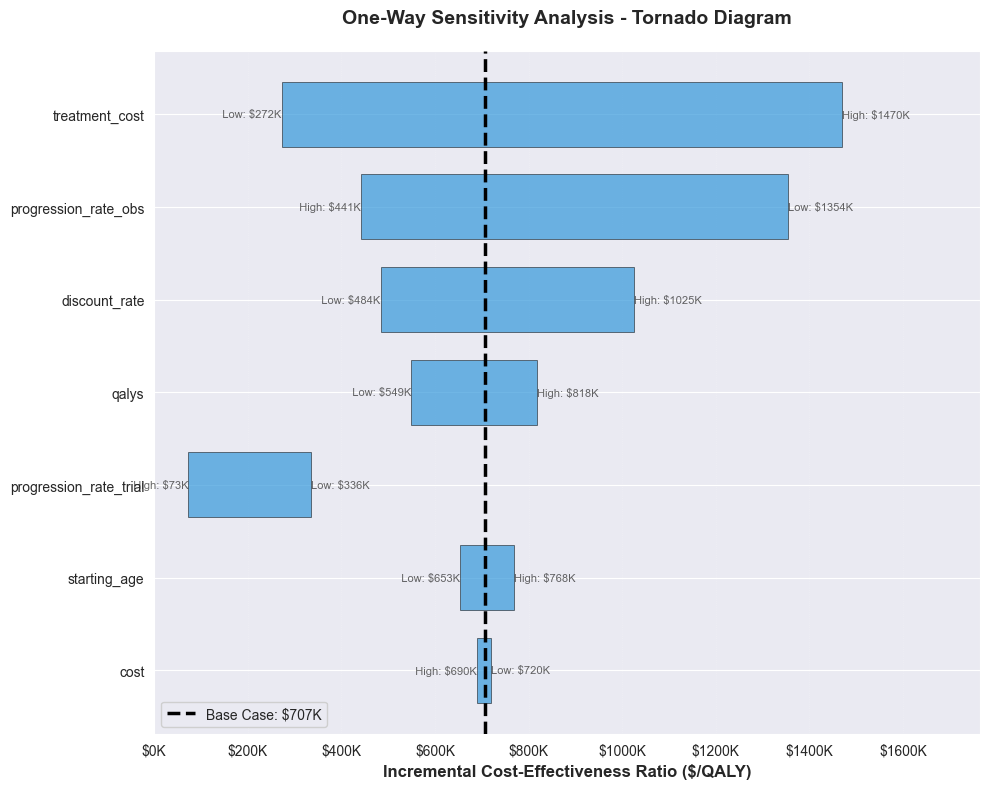

In [65]:
create_tornado_plot(sensitivity_df.drop_duplicates())
